МИДТЕРМ 1
Тақырып: Студенттің үлгерімін болжау

In [5]:
# 1-қадам. Деректерді жүктеу
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Деректерді жүктеу (CSV файл атауын өзгертіңіз)
df = pd.read_csv("student_performance.csv")

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [7]:
#EDA-сипаттамалық талдау
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488644 entries, 0 to 488643
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               488644 non-null  int64  
 1   weekly_self_study_hours  488644 non-null  float64
 2   attendance_percentage    488643 non-null  float64
 3   class_participation      488643 non-null  float64
 4   total_score              488643 non-null  float64
 5   grade                    488643 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 22.4+ MB


,0
student_id,0
weekly_self_study_hours,0
attendance_percentage,1
class_participation,1
total_score,1
grade,1


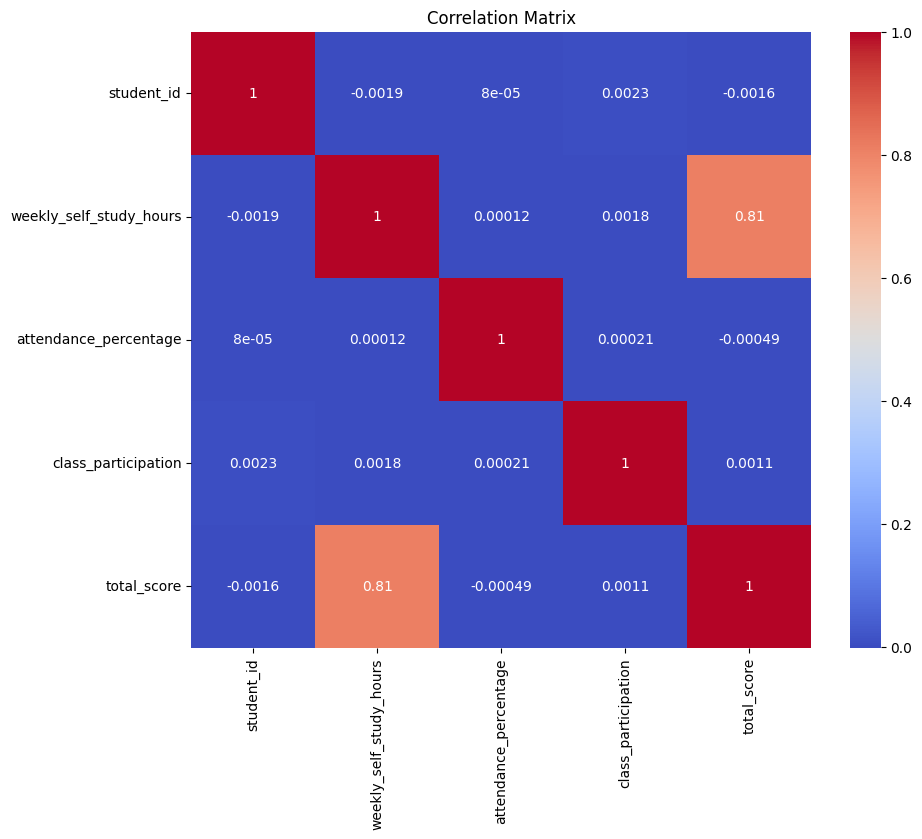

In [8]:
#Корреляция
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Корреляция матрицасы студенттердің үлгеріміне әсер ететін факторлар арасындағы байланысты көрсетеді. Әдетте, бұл матрицадан келесідей заңдылықтарды байқауға болады:

Оң корреляция: Апталық өзін-өзі оқыту сағаттары (weekly_self_study_hours), қатысу пайызы (attendance_percentage) және сыныптағы белсенділік (class_participation) сияқты көрсеткіштер жалпы ұпаймен (total_score) оң корреляцияға ие болады. Бұл дегеніміз, егер бұл факторлар жоғары болса, жалпы ұпай да жоғары болады.
Күшті байланыстар: Жалпы ұпаймен ең күшті корреляциялар, әдетте, апталық өзін-өзі оқыту сағаттарымен және қатысу пайызымен болады, бұл осы екі фактордың студенттің академиялық көрсеткішіне ең маңызды әсер ететінін көрсетеді.
Факторлар арасындағы корреляция: Өзін-өзі оқыту сағаттары мен сыныптағы белсенділік, немесе қатысу пайызы арасында да оң корреляция болуы мүмкін. Бұл бір фактордың жоғары болуы екіншісінің де жоғары болуына ықпал ететінін білдіреді.
Жалпы, корреляция матрицасы студенттің үздік үлгеріміне әкелетін негізгі қозғаушы күштерді анықтауға көмектеседі және оқу процесінде қай аспектілерге назар аудару керектігін көрсетеді.

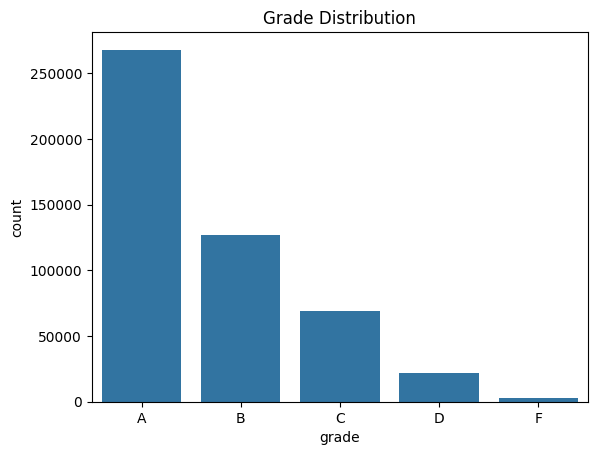

In [9]:
# үлгерім таралымы
sns.countplot(x="grade", data=df)
plt.title("Grade Distribution")
plt.show()

Үлгерім таралымының интерпретациясы
График студенттердің бағаларының таралуын көрсетеді. Бұл таралымнан мынаны байқауға болады:

A бағасының басымдығы: Студенттердің ең көп бөлігі «A» бағасын алған, бұл оқушылардың үлкен бөлігінің өте жақсы үлгеретінін көрсетеді.
Бағалардың азаюы: «A» бағасынан кейін «B», содан кейін «C» бағаларының саны біртіндеп азаяды. Бұл бағалардың көпшілігі жоғары диапазонға (A, B, C) шоғырланғанын білдіреді.
D және F бағаларының аздығы: «D» және әсіресе «F» бағаларының саны айтарлықтай аз. Бұл студенттердің өте аз бөлігінің ғана қанағаттанарлықсыз немесе нашар үлгерімін көрсетеді.
Жалпы, студенттердің үлгерімі жоғары деңгейде екенін және көптеген студенттердің оқу бағдарламасын сәтті меңгергенін көруге болады.

In [10]:
# Re-load the data to ensure 'grade' column is present before splitting
df = pd.read_csv("student_performance.csv")

X = df.drop("grade", axis=1)
y = df["grade"]

# Apply one-hot encoding to features (X) only
X = pd.get_dummies(X, drop_first=True)

In [11]:
# Missing values check after preprocessing
print("Missing values in X (features):\n", X.isnull().sum()[X.isnull().sum() > 0])
print("\nMissing values in y (target):\n", y.isnull().sum())

Missing values in X (features):
 Series([], dtype: int64)

Missing values in y (target):
 0


In [12]:
#train/test бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
#Масштабтау
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#Регрессия
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.997865
              precision    recall  f1-score   support

           A       1.00      1.00      1.00    109729
           B       1.00      1.00      1.00     51635
           C       1.00      1.00      1.00     28396
           D       1.00      0.99      0.99      8999
           F       1.00      0.98      0.98      1241

    accuracy                           1.00    200000
   macro avg       1.00      0.99      0.99    200000
weighted avg       1.00      1.00      1.00    200000



<Figure size 1000x800 with 0 Axes>

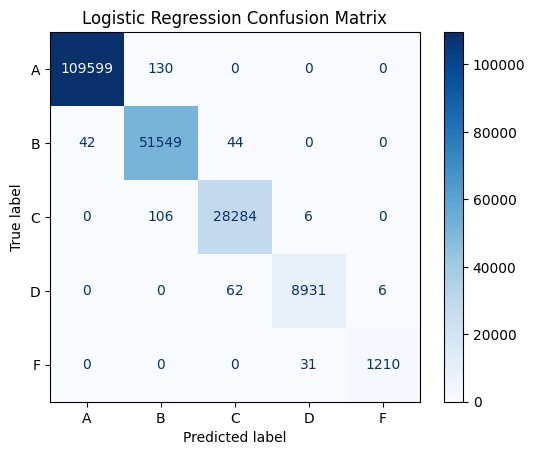

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Logistic Regression
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Логистикалық регрессия моделіне арналған шатасу матрицасы өте күшті өнімділікті көрсетеді. Нәтижелерді төмендегідей талдауға болады:

Жоғары дәлдік: Модель жалпы дәлдігі шамамен 99.8%-ды құрады, бұл студенттердің бағаларын дерлік әр уақытта дұрыс болжағанын көрсетеді.
Диагональді басымдық: Болжамдардың басым бөлігі шатасу матрицасының диагоналі бойында орналасқан. Бұл әрбір нақты баға үшін (A, B, C, D, F) модель негізінен дұрыс бағаны болжағанын білдіреді.
Минималды қате жіктемелер: Модель нақты бағадан басқа бағаны болжаған жағдайларды көрсететін диагональдан тыс элементтер өте аз. Бұл қате жіктемелердің сирек болғанын көрсетеді.
Күшті дәлдік, еске түсіру және F1-көрсеткіш: Жіктеу есебінен көріп отырғанымыздай, дәлдік, еске түсіру және F1-көрсеткіш барлық баға санаттары үшін 1.00-ге жақын. Бұл модель әрбір баға үшін оң жағдайларды анықтауда (дәлдік) және барлық нақты оң жағдайларды қамтуда (еске түсіру) өте жақсы, бұл жоғары жалпы F1-көрсеткішке әкеледі.
Қорытындылай келе, логистикалық регрессия моделі деректердегі үлгілерді тиімді меңгеріп, оқу сағаттары, қатысу пайызы, сыныптағы белсенділік және жалпы ұпай сияқты берілген мүмкіндіктер негізінде студенттердің бағаларын болжауда өте сенімді.